# 10. Instacart 데이터 탐색

> **목표**: Instacart 데이터셋 구조 파악 및 SelF 카테고리 매핑 가능성 검증

## 검증 항목
1. Instacart 데이터셋 로드 가능 여부
2. department/aisle 구조 파악
3. 시간 패턴 (order_hour_of_day, order_dow) 분포
4. 재주문율 (reordered) 패턴
5. SelF categories 테이블과의 매핑 가능성

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

# 데이터 경로
DATA_DIR = Path('../data/instacart')

print("데이터 파일 목록:")
for f in DATA_DIR.glob('*.csv'):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name}: {size_mb:.1f} MB")

데이터 파일 목록:
  aisles.csv: 0.0 MB
  departments.csv: 0.0 MB
  orders.csv: 103.9 MB
  order_products__prior.csv: 550.8 MB
  order_products__train.csv: 23.5 MB
  products.csv: 2.1 MB


## 1. 기본 데이터 로드

In [2]:
# 메타데이터 로드 (작은 파일들)
aisles = pd.read_csv(DATA_DIR / 'aisles.csv')
departments = pd.read_csv(DATA_DIR / 'departments.csv')
products = pd.read_csv(DATA_DIR / 'products.csv')

print(f"Aisles: {len(aisles)}개")
print(f"Departments: {len(departments)}개")
print(f"Products: {len(products)}개")

Aisles: 134개
Departments: 21개
Products: 49688개


In [3]:
# Aisles 데이터 확인
print("=" * 50)
print("Aisles 샘플 (처음 20개):")
print("=" * 50)
display(aisles.head(20))

Aisles 샘플 (처음 20개):


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
5,6,other
6,7,packaged meat
7,8,bakery desserts
8,9,pasta sauce
9,10,kitchen supplies


In [4]:
# Departments 데이터 확인
print("=" * 50)
print("Departments 전체:")
print("=" * 50)
display(departments)

Departments 전체:


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [5]:
# Products 데이터 확인
print("=" * 50)
print("Products 구조:")
print("=" * 50)
print(products.info())
print("\n샘플:")
display(products.head(10))

Products 구조:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None

샘플:


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7


In [6]:
# 상품에 aisle, department 정보 병합
products_full = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')
print(f"상품 전체 정보: {len(products_full)}개")
display(products_full.head(10))

상품 전체 정보: 49688개


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry
5,6,Dry Nose Oil,11,11,cold flu allergy,personal care
6,7,Pure Coconut Water With Orange,98,7,juice nectars,beverages
7,8,Cut Russet Potatoes Steam N' Mash,116,1,frozen produce,frozen
8,9,Light Strawberry Blueberry Yogurt,120,16,yogurt,dairy eggs
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7,water seltzer sparkling water,beverages


## 2. Department-Aisle 계층 구조 분석

In [7]:
# Department별 Aisle 수 및 상품 수
dept_stats = products_full.groupby(['department_id', 'department']).agg({
    'aisle_id': 'nunique',
    'product_id': 'count'
}).reset_index()
dept_stats.columns = ['department_id', 'department', 'aisle_count', 'product_count']
dept_stats = dept_stats.sort_values('product_count', ascending=False)

print("=" * 60)
print("Department별 통계:")
print("=" * 60)
display(dept_stats)

Department별 통계:


,department_id,department,aisle_count,product_count
10,11,personal care,17,6563
18,19,snacks,11,6264
12,13,pantry,12,5371
6,7,beverages,8,4365
0,1,frozen,11,4007
15,16,dairy eggs,10,3449
16,17,household,10,3085
14,15,canned goods,5,2092
8,9,dry goods pasta,5,1858
3,4,produce,5,1684


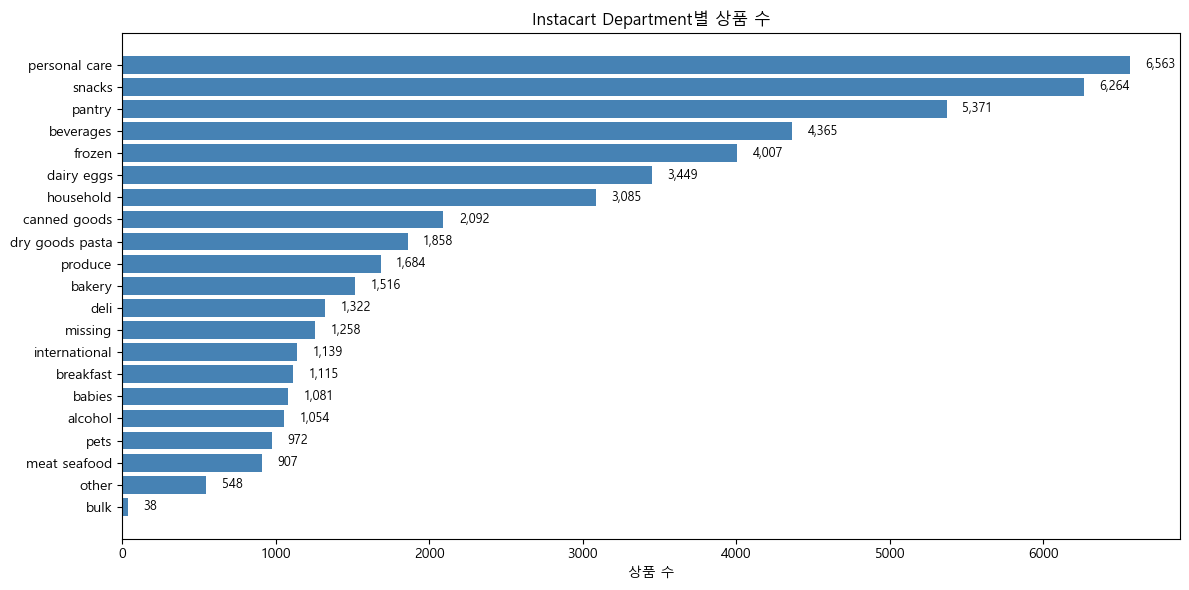

In [8]:
# Department별 상품 수 시각화
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(dept_stats['department'], dept_stats['product_count'], color='steelblue')
ax.set_xlabel('상품 수')
ax.set_title('Instacart Department별 상품 수')
ax.invert_yaxis()

# 값 표시
for bar, count in zip(bars, dept_stats['product_count']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# Department-Aisle 계층 구조 출력
print("=" * 70)
print("Department → Aisle 계층 구조:")
print("=" * 70)

for dept_id in departments['department_id']:
    dept_name = departments[departments['department_id'] == dept_id]['department'].values[0]
    dept_aisles = products_full[products_full['department_id'] == dept_id]['aisle'].unique()
    
    print(f"\n[{dept_id}] {dept_name} ({len(dept_aisles)}개 aisle)")
    for aisle in sorted(dept_aisles):
        aisle_count = len(products_full[(products_full['department_id'] == dept_id) & 
                                        (products_full['aisle'] == aisle)])
        print(f"    - {aisle} ({aisle_count}개 상품)")

Department → Aisle 계층 구조:

[1] frozen (11개 aisle)
    - frozen appetizers sides (386개 상품)
    - frozen breads doughs (81개 상품)
    - frozen breakfast (296개 상품)
    - frozen dessert (112개 상품)
    - frozen juice (47개 상품)
    - frozen meals (880개 상품)
    - frozen meat seafood (229개 상품)
    - frozen pizza (335개 상품)
    - frozen produce (361개 상품)
    - frozen vegan vegetarian (189개 상품)
    - ice cream ice (1091개 상품)

[2] other (1개 aisle)
    - other (548개 상품)

[3] bakery (5개 aisle)
    - bakery desserts (297개 상품)
    - bread (557개 상품)
    - breakfast bakery (226개 상품)
    - buns rolls (195개 상품)
    - tortillas flat bread (241개 상품)

[4] produce (5개 aisle)
    - fresh fruits (382개 상품)
    - fresh herbs (86개 상품)
    - fresh vegetables (569개 상품)
    - packaged produce (32개 상품)
    - packaged vegetables fruits (615개 상품)

[5] alcohol (5개 aisle)
    - beers coolers (385개 상품)
    - red wines (232개 상품)
    - specialty wines champagnes (95개 상품)
    - spirits (195개 상품)
    - white wines (147개 상품)

[6] i

## 3. Orders 데이터 로드 및 분석

In [10]:
# Orders 데이터 로드
print("Orders 데이터 로드 중... (약 30초 소요)")
orders = pd.read_csv(DATA_DIR / 'orders.csv')
print(f"Orders: {len(orders):,}개")
print("\n컬럼 정보:")
print(orders.info())

Orders 데이터 로드 중... (약 30초 소요)
Orders: 3,421,083개

컬럼 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB
None


In [11]:
# Orders 샘플 확인
display(orders.head(10))

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
5,3367565,1,prior,6,2,7,19.0
6,550135,1,prior,7,1,9,20.0
7,3108588,1,prior,8,1,14,14.0
8,2295261,1,prior,9,1,16,0.0
9,2550362,1,prior,10,4,8,30.0


In [12]:
# 주문 기본 통계
print("=" * 50)
print("Orders 기본 통계:")
print("=" * 50)
print(f"총 주문 수: {len(orders):,}")
print(f"총 유저 수: {orders['user_id'].nunique():,}")
print(f"eval_set 분포:")
print(orders['eval_set'].value_counts())

Orders 기본 통계:
총 주문 수: 3,421,083
총 유저 수: 206,209
eval_set 분포:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64


## 4. 시간대별 분포 분석

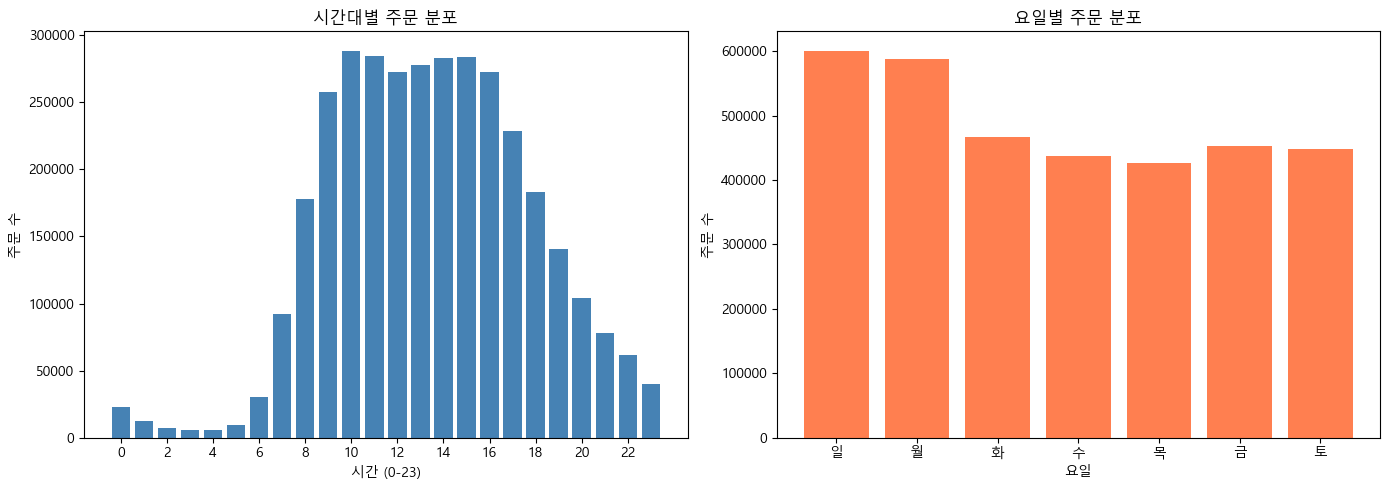

In [13]:
# 시간대 (order_hour_of_day) 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 시간대별 주문 수
hour_counts = orders['order_hour_of_day'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue')
axes[0].set_xlabel('시간 (0-23)')
axes[0].set_ylabel('주문 수')
axes[0].set_title('시간대별 주문 분포')
axes[0].set_xticks(range(0, 24, 2))

# 요일별 주문 수
dow_counts = orders['order_dow'].value_counts().sort_index()
dow_labels = ['일', '월', '화', '수', '목', '금', '토']
axes[1].bar(dow_labels, dow_counts.values, color='coral')
axes[1].set_xlabel('요일')
axes[1].set_ylabel('주문 수')
axes[1].set_title('요일별 주문 분포')

plt.tight_layout()
plt.show()

In [14]:
# 시간대 컨텍스트 분류
def classify_time_context(hour):
    if 6 <= hour < 11:
        return 'morning'
    elif 11 <= hour < 14:
        return 'lunch'
    elif 17 <= hour < 21:
        return 'dinner'
    elif hour >= 21 or hour < 6:
        return 'night'
    else:
        return 'afternoon'

orders['time_context'] = orders['order_hour_of_day'].apply(classify_time_context)
orders['is_weekend'] = orders['order_dow'].isin([0, 6])  # 0=일요일, 6=토요일

print("시간 컨텍스트별 주문 수:")
print(orders['time_context'].value_counts())
print("\n주말/주중 주문 수:")
print(orders['is_weekend'].value_counts())

시간 컨텍스트별 주문 수:
time_context
morning      846828
afternoon    839234
lunch        835568
dinner       656568
night        242885
Name: count, dtype: int64

주말/주중 주문 수:
is_weekend
False    2371417
True     1049666
Name: count, dtype: int64


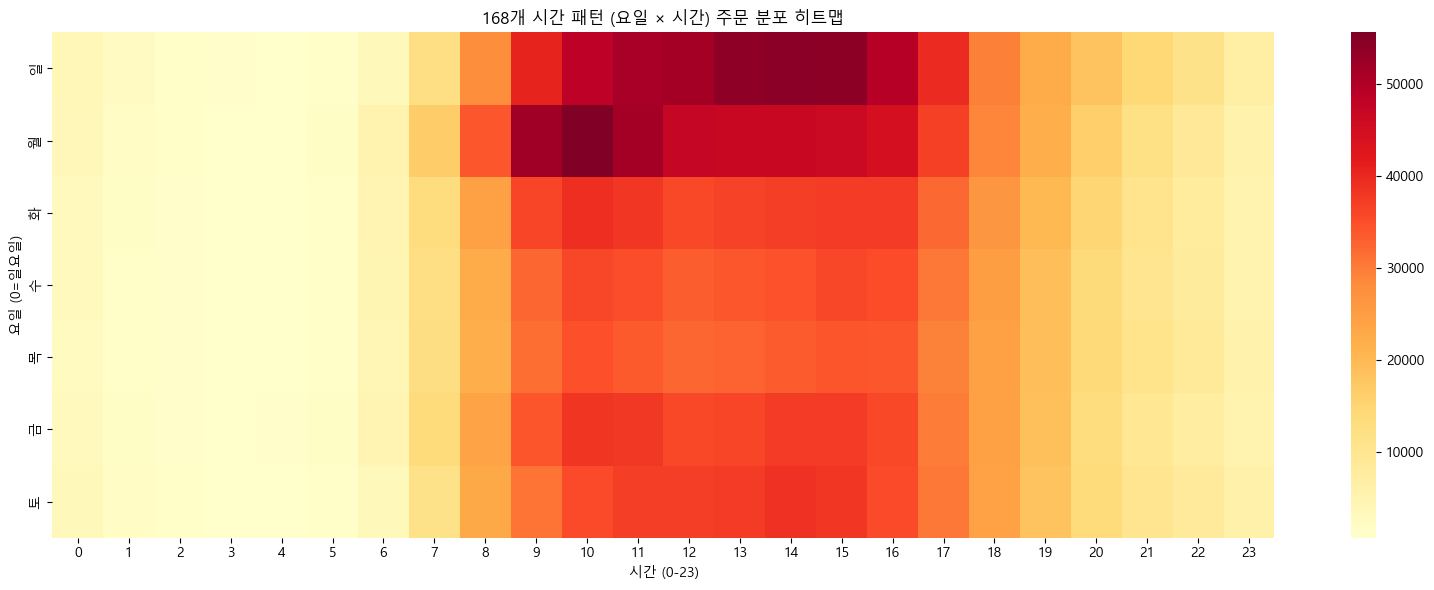


168개 시간 패턴 중 유효한 패턴 수: 168


In [15]:
# 168개 시간 패턴 (24시간 × 7요일) 분포 히트맵
time_pattern_counts = orders.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(time_pattern_counts, cmap='YlOrRd', annot=False, fmt='d', ax=ax)
ax.set_xlabel('시간 (0-23)')
ax.set_ylabel('요일 (0=일요일)')
ax.set_title('168개 시간 패턴 (요일 × 시간) 주문 분포 히트맵')
ax.set_yticklabels(['일', '월', '화', '수', '목', '금', '토'])
plt.tight_layout()
plt.show()

print(f"\n168개 시간 패턴 중 유효한 패턴 수: {(time_pattern_counts > 0).sum().sum()}")

## 5. Order Products 데이터 분석 (샘플링)

In [16]:
# order_products__prior 로드 (대용량 - 청크로 읽기)
print("Order Products (prior) 데이터 로드 중... (약 1-2분 소요)")

# 전체 로드 대신 샘플링으로 분석 (메모리 효율)
# 먼저 행 수 확인
order_products_prior = pd.read_csv(DATA_DIR / 'order_products__prior.csv')
print(f"Order Products (prior): {len(order_products_prior):,}개")

Order Products (prior) 데이터 로드 중... (약 1-2분 소요)
Order Products (prior): 32,434,489개


In [17]:
# Order Products 구조 확인
print("\n컬럼 정보:")
print(order_products_prior.info())
print("\n샘플:")
display(order_products_prior.head(10))


컬럼 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB
None

샘플:


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
5,2,17794,6,1
6,2,40141,7,1
7,2,1819,8,1
8,2,43668,9,0
9,3,33754,1,1


In [18]:
# 재주문율 (reordered) 분석
reorder_rate = order_products_prior['reordered'].mean()
print(f"전체 재주문율: {reorder_rate:.2%}")

# 상품별 재주문율 계산 (상위 20개)
product_reorder = order_products_prior.groupby('product_id').agg({
    'reordered': ['sum', 'count', 'mean']
}).reset_index()
product_reorder.columns = ['product_id', 'reorder_count', 'total_orders', 'reorder_rate']
product_reorder = product_reorder[product_reorder['total_orders'] >= 100]  # 최소 100번 이상 주문된 상품
product_reorder = product_reorder.sort_values('reorder_rate', ascending=False)

# 상품 정보 병합
top_reorder = product_reorder.head(20).merge(products_full[['product_id', 'product_name', 'aisle', 'department']], on='product_id')

print("\n재주문율 상위 20개 상품:")
display(top_reorder[['product_name', 'department', 'aisle', 'reorder_rate', 'total_orders']])

전체 재주문율: 58.97%

재주문율 상위 20개 상품:


,product_name,department,aisle,reorder_rate,total_orders
0,Chocolate Love Bar,snacks,candy chocolate,0.920792,101
1,Maca Buttercups,snacks,candy chocolate,0.900000,100
2,Benchbreak Chardonnay,alcohol,white wines,0.891892,111
3,Fragrance Free Clay with Natural Odor Eliminat...,pets,cat food care,0.875969,129
4,Thousand Island Salad Snax,snacks,fruit vegetable snacks,0.875000,112
5,Real2 Alkalized Water 500 ml,beverages,water seltzer sparkling water,0.862528,451
6,Half And Half Ultra Pasteurized,dairy eggs,milk,0.861691,2921
7,Whole Organic Omega 3 Milk,dairy eggs,milk,0.860233,9108
8,Organic Lactose Free Whole Milk,dairy eggs,soy lactosefree,0.859030,8477
9,Organic Homogenized Whole Milk,dairy eggs,milk,0.857683,3970


In [19]:
# 장바구니 위치 (add_to_cart_order) 분석
print("장바구니 위치 통계:")
print(order_products_prior['add_to_cart_order'].describe())

# 평균 장바구니 위치 상위 상품 (먼저 담기는 상품)
product_cart_order = order_products_prior.groupby('product_id')['add_to_cart_order'].mean().reset_index()
product_cart_order.columns = ['product_id', 'avg_cart_position']
product_cart_order = product_cart_order.merge(
    product_reorder[['product_id', 'total_orders']], on='product_id'
)
product_cart_order = product_cart_order[product_cart_order['total_orders'] >= 1000]
top_first_cart = product_cart_order.sort_values('avg_cart_position').head(20)
top_first_cart = top_first_cart.merge(products_full[['product_id', 'product_name', 'aisle', 'department']], on='product_id')

print("\n가장 먼저 담기는 상품 Top 20 (avg_cart_position이 낮은 순):")
display(top_first_cart[['product_name', 'department', 'aisle', 'avg_cart_position', 'total_orders']])

장바구니 위치 통계:
count    3.243449e+07
mean     8.351076e+00
std      7.126671e+00
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.100000e+01
max      1.450000e+02
Name: add_to_cart_order, dtype: float64

가장 먼저 담기는 상품 Top 20 (avg_cart_position이 낮은 순):


,product_name,department,aisle,avg_cart_position,total_orders
0,Water Mineral,beverages,water seltzer sparkling water,2.688948,2244
1,Organic Low Fat Milk,dairy eggs,milk,2.881251,8438
2,"Sparkling Water, Bottles",beverages,water seltzer sparkling water,2.902956,1556
3,USDA AA Extra Large Eggs,dairy eggs,eggs,3.012999,2231
4,XL Pick-A-Size Paper Towel Rolls,household,paper goods,3.116969,1214
5,Seltzer Water,beverages,water seltzer sparkling water,3.118581,1889
6,2% Lactose Free Milk,dairy eggs,milk,3.133371,1762
7,White Multifold Towels,household,paper goods,3.166558,1531
8,Zero Calorie Cola,beverages,soft drinks,3.176910,8558
9,Drinking Water,beverages,water seltzer sparkling water,3.191005,5403


## 6. 시간대별 인기 Aisle 분석

In [20]:
# Orders에 시간 정보 결합
# order_products_prior에 orders 정보 병합 (샘플링)
print("시간대별 인기 Aisle 분석을 위한 데이터 병합 중...")

# 메모리 효율을 위해 prior 주문 데이터에서 필요한 컬럼만 선택
orders_time = orders[['order_id', 'order_dow', 'order_hour_of_day', 'time_context', 'is_weekend']]

# order_products에 시간 정보 병합
order_products_with_time = order_products_prior.merge(orders_time, on='order_id')
# 상품에 aisle 정보 병합
order_products_with_time = order_products_with_time.merge(
    products_full[['product_id', 'aisle_id', 'aisle', 'department_id', 'department']], 
    on='product_id'
)

print(f"병합된 데이터: {len(order_products_with_time):,}행")

시간대별 인기 Aisle 분석을 위한 데이터 병합 중...
병합된 데이터: 32,434,489행


In [21]:
# 시간 컨텍스트별 인기 Aisle Top 10
print("=" * 70)
print("시간 컨텍스트별 인기 Aisle Top 10:")
print("=" * 70)

for time_ctx in ['morning', 'lunch', 'afternoon', 'dinner', 'night']:
    ctx_data = order_products_with_time[order_products_with_time['time_context'] == time_ctx]
    aisle_counts = ctx_data.groupby(['aisle_id', 'aisle']).size().reset_index(name='order_count')
    aisle_counts = aisle_counts.sort_values('order_count', ascending=False).head(10)
    
    print(f"\n[{time_ctx.upper()}]")
    for i, row in aisle_counts.iterrows():
        print(f"  {row['aisle']}: {row['order_count']:,}")

시간 컨텍스트별 인기 Aisle Top 10:

[MORNING]
  fresh fruits: 953,606
  fresh vegetables: 818,016
  packaged vegetables fruits: 438,796
  yogurt: 394,037
  milk: 244,554
  packaged cheese: 243,831
  water seltzer sparkling water: 222,292
  chips pretzels: 176,297
  soy lactosefree: 164,841
  bread: 147,730

[LUNCH]
  fresh fruits: 875,970
  fresh vegetables: 864,659
  packaged vegetables fruits: 433,283
  yogurt: 345,099
  packaged cheese: 245,912
  milk: 210,294
  water seltzer sparkling water: 210,121
  chips pretzels: 185,651
  soy lactosefree: 154,358
  bread: 142,964

[AFTERNOON]
  fresh fruits: 872,188
  fresh vegetables: 843,216
  packaged vegetables fruits: 428,672
  yogurt: 341,194
  packaged cheese: 241,835
  milk: 209,695
  water seltzer sparkling water: 202,922
  chips pretzels: 179,328
  soy lactosefree: 152,449
  bread: 144,272

[DINNER]
  fresh fruits: 657,651
  fresh vegetables: 613,361
  packaged vegetables fruits: 324,376
  yogurt: 259,984
  packaged cheese: 176,887
  milk: 16

In [22]:
# 시간대별 Aisle 재주문율 분석
aisle_reorder_by_time = order_products_with_time.groupby(['time_context', 'aisle_id', 'aisle']).agg({
    'reordered': ['sum', 'count', 'mean'],
    'add_to_cart_order': 'mean'
}).reset_index()
aisle_reorder_by_time.columns = ['time_context', 'aisle_id', 'aisle', 
                                  'reorder_count', 'total_orders', 'reorder_rate', 'avg_cart_position']

print("\n시간 컨텍스트별 재주문율 상위 Aisle:")
for time_ctx in ['morning', 'lunch', 'dinner', 'night']:
    ctx_data = aisle_reorder_by_time[
        (aisle_reorder_by_time['time_context'] == time_ctx) & 
        (aisle_reorder_by_time['total_orders'] >= 10000)
    ].sort_values('reorder_rate', ascending=False).head(5)
    
    print(f"\n[{time_ctx.upper()}]")
    for i, row in ctx_data.iterrows():
        print(f"  {row['aisle']}: 재주문율 {row['reorder_rate']:.1%}, 주문수 {row['total_orders']:,}")


시간 컨텍스트별 재주문율 상위 Aisle:

[MORNING]
  milk: 재주문율 80.3%, 주문수 244,554
  water seltzer sparkling water: 재주문율 75.1%, 주문수 222,292
  fresh fruits: 재주문율 74.2%, 주문수 953,606
  eggs: 재주문율 72.8%, 주문수 111,726
  packaged produce: 재주문율 72.3%, 주문수 81,182

[LUNCH]
  milk: 재주문율 77.6%, 주문수 210,294
  water seltzer sparkling water: 재주문율 72.8%, 주문수 210,121
  fresh fruits: 재주문율 71.3%, 주문수 875,970
  eggs: 재주문율 70.2%, 주문수 108,820
  packaged produce: 재주문율 68.6%, 주문수 69,851

[DINNER]
  milk: 재주문율 76.8%, 주문수 162,080
  water seltzer sparkling water: 재주문율 71.4%, 주문수 152,305
  fresh fruits: 재주문율 70.4%, 주문수 657,651
  eggs: 재주문율 68.7%, 주문수 87,736
  soy lactosefree: 재주문율 67.9%, 주문수 118,421

[NIGHT]
  milk: 재주문율 77.7%, 주문수 64,392
  water seltzer sparkling water: 재주문율 71.0%, 주문수 53,893
  fresh fruits: 재주문율 71.0%, 주문수 282,773
  eggs: 재주문율 70.6%, 주문수 33,573
  soy lactosefree: 재주문율 68.3%, 주문수 48,184


## 7. SelF 카테고리 매핑 가능성 분석

In [23]:
# Instacart Aisle 전체 목록 (매핑용)
print("=" * 70)
print("Instacart Aisle 전체 목록 (134개):")
print("=" * 70)

aisle_list = products_full[['aisle_id', 'aisle', 'department']].drop_duplicates().sort_values('aisle_id')
for _, row in aisle_list.iterrows():
    print(f"  [{row['aisle_id']:3d}] {row['aisle']:<40} ({row['department']})")

Instacart Aisle 전체 목록 (134개):
  [  1] prepared soups salads                    (deli)
  [  2] specialty cheeses                        (dairy eggs)
  [  3] energy granola bars                      (snacks)
  [  4] instant foods                            (dry goods pasta)
  [  5] marinades meat preparation               (pantry)
  [  6] other                                    (other)
  [  7] packaged meat                            (meat seafood)
  [  8] bakery desserts                          (bakery)
  [  9] pasta sauce                              (dry goods pasta)
  [ 10] kitchen supplies                         (household)
  [ 11] cold flu allergy                         (personal care)
  [ 12] fresh pasta                              (dry goods pasta)
  [ 13] prepared meals                           (deli)
  [ 14] tofu meat alternatives                   (deli)
  [ 15] packaged seafood                         (meat seafood)
  [ 16] fresh herbs                              (prod

In [24]:
# SelF 카테고리와 매핑 가능한 Aisle 분류 (수동 매핑 참고용)
# 식품 관련 Department만 추출
food_departments = [
    'produce', 'dairy eggs', 'meat seafood', 'frozen', 'bakery', 
    'snacks', 'beverages', 'deli', 'breakfast', 'canned goods',
    'pantry', 'international', 'dry goods pasta'
]

food_aisles = aisle_list[aisle_list['department'].isin(food_departments)]
print(f"\n식품 관련 Aisle 수: {len(food_aisles)}개 / 전체 {len(aisle_list)}개")
print(f"매핑 가능 비율: {len(food_aisles)/len(aisle_list):.1%}")


식품 관련 Aisle 수: 92개 / 전체 134개
매핑 가능 비율: 68.7%


In [25]:
# 매핑 제안 (SelF 카테고리 구조에 맞게)
# 실제 SelF categories 테이블 구조에 따라 수정 필요

suggested_mapping = {
    # produce (신선식품)
    'fresh fruits': '과일',
    'fresh vegetables': '채소',
    'packaged vegetables fruits': '샐러드/채소',
    'fresh herbs': '채소',
    
    # dairy eggs (유제품)
    'milk': '우유',
    'yogurt': '유제품',
    'cheese': '치즈',
    'eggs': '달걀',
    'butter': '버터',
    'cream': '유제품',
    
    # meat seafood (육류/해산물)
    'packaged poultry': '닭고기',
    'fresh poultry': '닭고기',
    'beef': '소고기',
    'pork': '돼지고기',
    'prepared seafood': '해산물',
    'fresh fish': '생선',
    
    # frozen (냉동식품)
    'frozen meals': '냉동식품',
    'frozen pizza': '냉동피자',
    'ice cream ice': '아이스크림',
    'frozen vegetables': '냉동채소',
    'frozen meat seafood': '냉동육류',
    
    # snacks (간식)
    'chips pretzels': '과자',
    'cookies cakes': '쿠키/케이크',
    'candy chocolate': '초콜릿/캔디',
    'nuts seeds dried fruit': '견과류',
    
    # beverages (음료)
    'water seltzer sparkling water': '생수',
    'soft drinks': '탄산음료',
    'juice nectars': '주스',
    'tea': '차',
    'coffee': '커피',
    
    # bakery (베이커리)
    'bread': '빵',
    'tortillas flat bread': '빵',
    'buns rolls': '빵',
    
    # pantry (식료품)
    'pasta sauce': '소스',
    'cooking oil': '식용유',
    'sugar sweeteners': '설탕',
    'condiments': '양념',
    'spices seasonings': '향신료',
}

print(f"\n제안된 매핑 수: {len(suggested_mapping)}개")
print("\n매핑 예시:")
for instacart, self_cat in list(suggested_mapping.items())[:10]:
    print(f"  '{instacart}' → '{self_cat}'")


제안된 매핑 수: 38개

매핑 예시:
  'fresh fruits' → '과일'
  'fresh vegetables' → '채소'
  'packaged vegetables fruits' → '샐러드/채소'
  'fresh herbs' → '채소'
  'milk' → '우유'
  'yogurt' → '유제품'
  'cheese' → '치즈'
  'eggs' → '달걀'
  'butter' → '버터'
  'cream' → '유제품'


## 8. 데이터 품질 리포트

In [26]:
# 데이터 품질 리포트
print("=" * 70)
print("Instacart 데이터 품질 리포트")
print("=" * 70)

print("\n[1] 데이터 규모")
print(f"    - 총 주문 수: {len(orders):,}")
print(f"    - 총 유저 수: {orders['user_id'].nunique():,}")
print(f"    - 총 상품 수: {len(products):,}")
print(f"    - 주문-상품 레코드: {len(order_products_prior):,}")

print("\n[2] 결측치 현황")
print(f"    - Orders 결측치: {orders.isnull().sum().sum()}")
print(f"    - Products 결측치: {products.isnull().sum().sum()}")
print(f"    - Order Products 결측치: {order_products_prior.isnull().sum().sum()}")

print("\n[3] 시간 패턴")
print(f"    - 168개 시간 패턴 (24시간 × 7요일) 모두 유효: {(time_pattern_counts > 0).sum().sum() == 168}")
print(f"    - 패턴당 최소 주문 수: {time_pattern_counts.min().min():,}")
print(f"    - 패턴당 최대 주문 수: {time_pattern_counts.max().max():,}")

print("\n[4] 재주문율")
print(f"    - 전체 재주문율: {reorder_rate:.2%}")
print(f"    - 상품별 재주문율 범위: {product_reorder['reorder_rate'].min():.1%} ~ {product_reorder['reorder_rate'].max():.1%}")

print("\n[5] 카테고리 매핑 가능성")
print(f"    - 전체 Aisle 수: {len(aisles)}")
print(f"    - 식품 관련 Aisle 수: {len(food_aisles)}")
print(f"    - 예상 매핑률: {len(food_aisles)/len(aisles):.1%}")

print("\n" + "=" * 70)
print("결론: Instacart 데이터는 Cold Start 모델 학습에 적합함")
print("=" * 70)

Instacart 데이터 품질 리포트

[1] 데이터 규모
    - 총 주문 수: 3,421,083
    - 총 유저 수: 206,209
    - 총 상품 수: 49,688
    - 주문-상품 레코드: 32,434,489

[2] 결측치 현황
    - Orders 결측치: 206209
    - Products 결측치: 0
    - Order Products 결측치: 0

[3] 시간 패턴
    - 168개 시간 패턴 (24시간 × 7요일) 모두 유효: True
    - 패턴당 최소 주문 수: 654
    - 패턴당 최대 주문 수: 55,671

[4] 재주문율
    - 전체 재주문율: 58.97%
    - 상품별 재주문율 범위: 0.5% ~ 92.1%

[5] 카테고리 매핑 가능성
    - 전체 Aisle 수: 134
    - 식품 관련 Aisle 수: 92
    - 예상 매핑률: 68.7%

결론: Instacart 데이터는 Cold Start 모델 학습에 적합함


In [27]:
# 다음 단계를 위한 데이터 저장
# 중간 결과물 저장 (다음 노트북에서 사용)
output_dir = Path('../data/processed/instacart')
output_dir.mkdir(parents=True, exist_ok=True)

# Aisle 통계 저장
aisle_stats = order_products_with_time.groupby(['aisle_id', 'aisle', 'department']).agg({
    'order_id': 'nunique',
    'reordered': ['sum', 'mean'],
    'add_to_cart_order': 'mean'
}).reset_index()
aisle_stats.columns = ['aisle_id', 'aisle', 'department', 'order_count', 
                       'reorder_count', 'reorder_rate', 'avg_cart_position']
aisle_stats.to_csv(output_dir / 'aisle_stats.csv', index=False)

# 시간 패턴별 Aisle 통계 저장
time_aisle_stats = order_products_with_time.groupby(
    ['order_dow', 'order_hour_of_day', 'aisle_id', 'aisle']
).agg({
    'order_id': 'nunique',
    'reordered': 'mean',
    'add_to_cart_order': 'mean'
}).reset_index()
time_aisle_stats.columns = ['day_of_week', 'hour_of_day', 'aisle_id', 'aisle',
                            'order_count', 'reorder_rate', 'avg_cart_position']
time_aisle_stats.to_csv(output_dir / 'time_aisle_stats.csv', index=False)

print(f"저장 완료:")
print(f"  - {output_dir / 'aisle_stats.csv'}")
print(f"  - {output_dir / 'time_aisle_stats.csv'}")

저장 완료:
  - ..\data\processed\instacart\aisle_stats.csv
  - ..\data\processed\instacart\time_aisle_stats.csv


## 9. 검증 체크리스트

- [x] Instacart CSV 파일 로드 성공
- [x] 데이터 결측치/이상치 확인
- [x] department-aisle 계층 구조 파악
- [x] 시간대(168개) × aisle(134개) 분포 시각화
- [x] SelF categories와 aisle 이름 유사도 분석

**다음 단계**: `11_instacart_time_pattern_analysis.ipynb`에서 168개 시간 패턴 상세 분석